# **Metal Defect Detection Using CNN, SVM, and Random Forest**
### **Computer Vision Project**
**Objective:** Compare the performance of CNN, SVM, and Random Forest for detecting metal defects in images.

*By Swati Aggrawal and Vibha Sengar*  
*Date: 14/01/2025*

---


# 1. Setup and Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing Neccesary Libraries

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
from tensorflow import keras
import itertools
from skimage import io, feature
from sklearn.model_selection import train_test_split
from sklearn import svm
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from collections import Counter
from tensorflow.keras.models import load_model
from PIL import Image
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from mpl_toolkits.mplot3d import Axes3D
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense, Dropout,BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array

In [3]:
!pip install kaggle

In [4]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content/drive/MyDrive/kaggle'

In [5]:
!kaggle datasets download -d fantacher/neu-metal-surface-defects-data

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


In [6]:
# import zipfile

# file_path = '/content/neu-metal-surface-defects-data.zip'

# with zipfile.ZipFile(file_path, 'r') as zip_ref:
#     zip_ref.extractall('/content/drive/MyDrive/datasets')


# 2. Load and Preprocess Data

In [7]:
train_dir = '/content/drive/MyDrive/datasets/NEU Metal Surface Defects Data/train'
test_dir = '/content/drive/MyDrive/datasets/NEU Metal Surface Defects Data/test'
valid_dir = '/content/drive/MyDrive/datasets/NEU Metal Surface Defects Data/valid'

Creating data generators for training, validation, and test datasets. Training images are rescaled to [0,1] and augmented with random shear (0.2) and horizontal flips. Validation and test images are only rescaled, so no augmentation touches the evaluation data.

In [8]:
train_datagen = ImageDataGenerator(rescale=1./255,
                             shear_range=0.2,
#                              zoom_range=0.2,
                             horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir,
                                              target_size=(200, 200),
                                              batch_size=36,
                                              class_mode='categorical',
                                                    shuffle = True
                                              )

valid_generator = test_datagen.flow_from_directory(valid_dir,
                                              target_size=(200, 200),
                                              batch_size=36,
                                              class_mode='categorical'
                                              )

test_generator = test_datagen.flow_from_directory(test_dir,
                                              target_size=(200, 200),
                                              batch_size=36,
                                              class_mode='categorical',
                                              shuffle = False
                                              )


Found 1654 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.


Fixing corrupted Images

In [9]:
def verify_and_fix_images(directory):
    for subdir, _, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(subdir, file)
            try:
                with Image.open(filepath) as img:
                    img.verify()  # Check for corruption
                    # If no errors, image is fine
            except (IOError, SyntaxError, ValueError) as e:
                print(f"Error with image: {filepath}")
                print(f"Error message: {e}")
                try:
                    img = Image.open(filepath)
                    img.save(filepath, "JPEG")
                    print(f"Attempted to fix image: {filepath}")
                except Exception as e2:
                    print(f"Failed to fix image: {filepath}, {e2}")

# Verify and fix images in all directories
verify_and_fix_images(train_dir)
verify_and_fix_images(valid_dir)
verify_and_fix_images(test_dir)


Distribution of training dataset

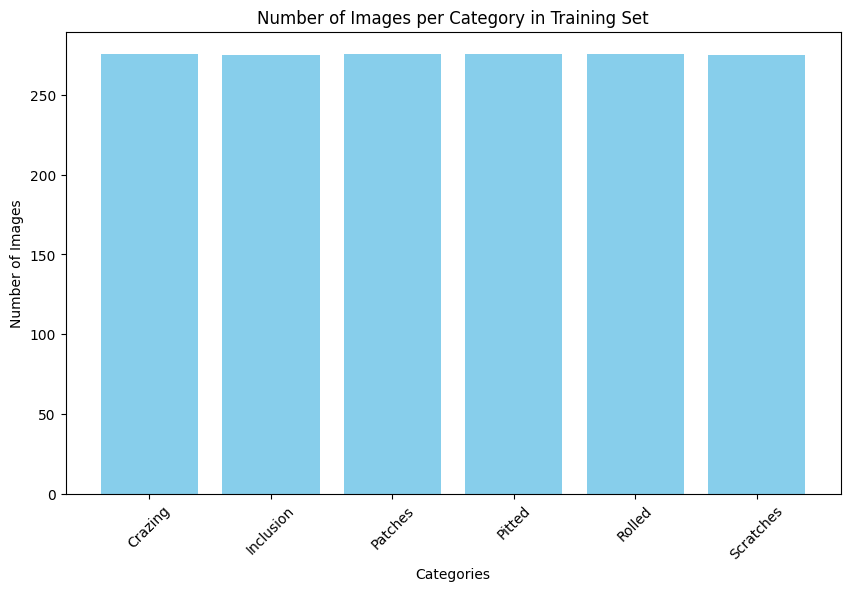

In [10]:
def count_images_per_category(directory):
    categories = os.listdir(directory)
    counts = Counter()

    for category in categories:
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            num_images = len(os.listdir(category_path))
            counts[category] = num_images

    return counts

# Count the images in each category for the training set
train_counts = count_images_per_category(train_dir)
plt.figure(figsize=(10, 6))
plt.bar(train_counts.keys(), train_counts.values(), color='skyblue')
plt.xlabel('Categories')
plt.ylabel('Number of Images')
plt.title('Number of Images per Category in Training Set')
plt.xticks(rotation=45)
plt.show()

In [11]:
for image_batch, labels_batch in train_generator:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(36, 200, 200, 3)
(36, 6)


Visualizing samples from the dataset

In [12]:
def get_sample_image(generator):
    images, labels = next(generator)
    image = images[0]
    label_index = np.argmax(labels[0])
    class_names=list(train_generator.class_indices.keys())
    label_name = class_names[label_index]

    return image, label_name


def sample_images(generator, nrows=4, ncols=4):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 15))

    for i in range(nrows*ncols):
        image, label_name = get_sample_image(generator)
        row = i // ncols
        col = i % ncols
        ax = axes[row][col]
        ax.imshow(image)
        ax.set_title(label_name)
        ax.axis('off')

    plt.show()

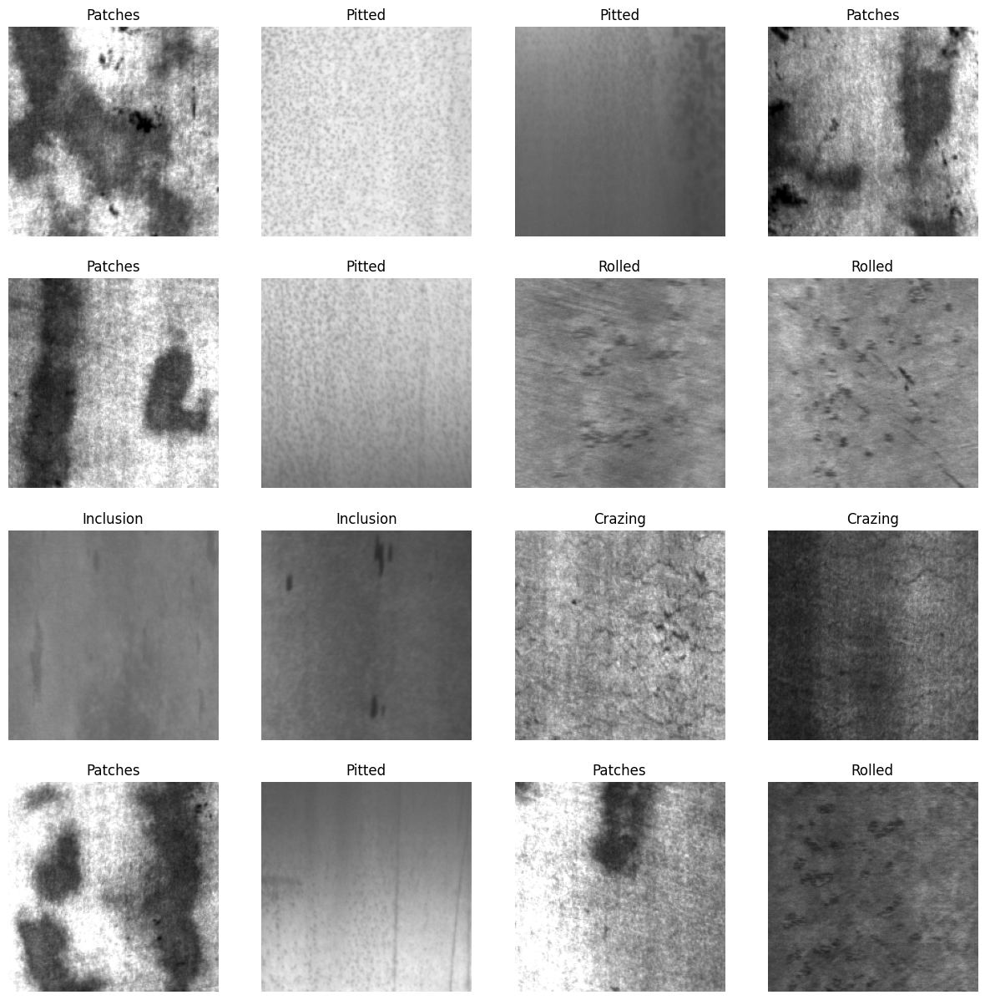

In [13]:
sample_images(train_generator, nrows=4, ncols=4)

In [14]:
def extract_features(generator):
    features = []
    labels = []
    batches_processed = 0

    for inputs_batch, labels_batch in generator:
        features.append(inputs_batch)
        labels.append(labels_batch)
        batches_processed += 1

        # Check if all samples have been processed
        if batches_processed * generator.batch_size >= generator.samples:
            break

    # Stack features and labels
    features = np.vstack(features)
    labels = np.vstack(labels)

    print(f"Processed {batches_processed} batches.")
    print(f"Total features shape: {features.shape}")
    print(f"Total labels shape: {labels.shape}")

    return features, labels

# Extract features and labels from generators
train_features, train_labels = extract_features(train_generator)
validation_features, validation_labels = extract_features(valid_generator)
test_features, test_labels = extract_features(test_generator)

# Flatten the features for PCA and t-SNE
num_samples, height, width, channels = train_features.shape
flattened_features = train_features.reshape(num_samples, height * width * channels)

print(f"Shape of flattened_features: {flattened_features.shape}")
print(f"Shape of train_labels: {train_labels.shape}")

Processed 46 batches.
Total features shape: (1654, 200, 200, 3)
Total labels shape: (1654, 6)
Processed 2 batches.
Total features shape: (72, 200, 200, 3)
Total labels shape: (72, 6)
Processed 2 batches.
Total features shape: (72, 200, 200, 3)
Total labels shape: (72, 6)
Shape of flattened_features: (1654, 120000)
Shape of train_labels: (1654, 6)


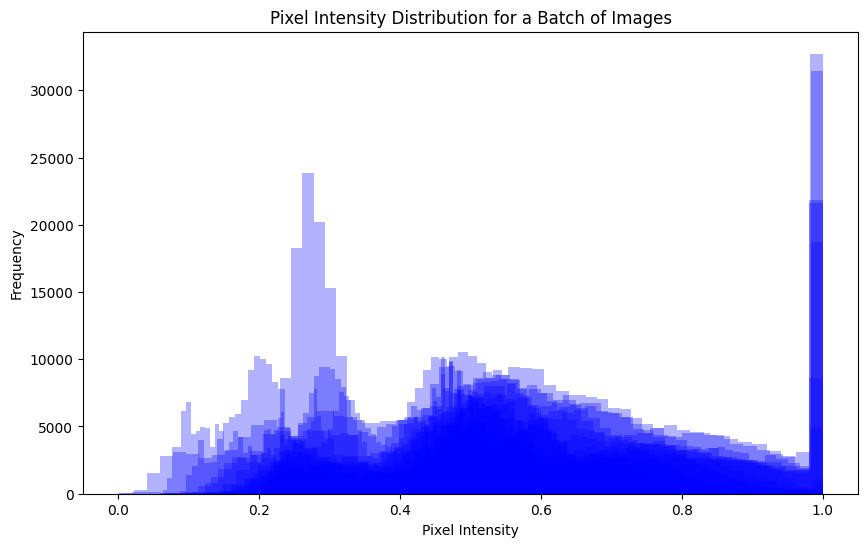

In [15]:
# 3. Pixel Intensity Distribution for a batch of images
def plot_pixel_intensity_distribution(generator, n_samples=36):
    images, _ = next(generator)
    plt.figure(figsize=(10, 6))
    for i in range(n_samples):
        image = images[i].ravel()
        plt.hist(image, bins=50, alpha=0.3, color='blue')
    plt.title('Pixel Intensity Distribution for a Batch of Images')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.show()

plot_pixel_intensity_distribution(train_generator)

Reducing the dimensionality of the dataset using PCA and visualizing the results in 3D.

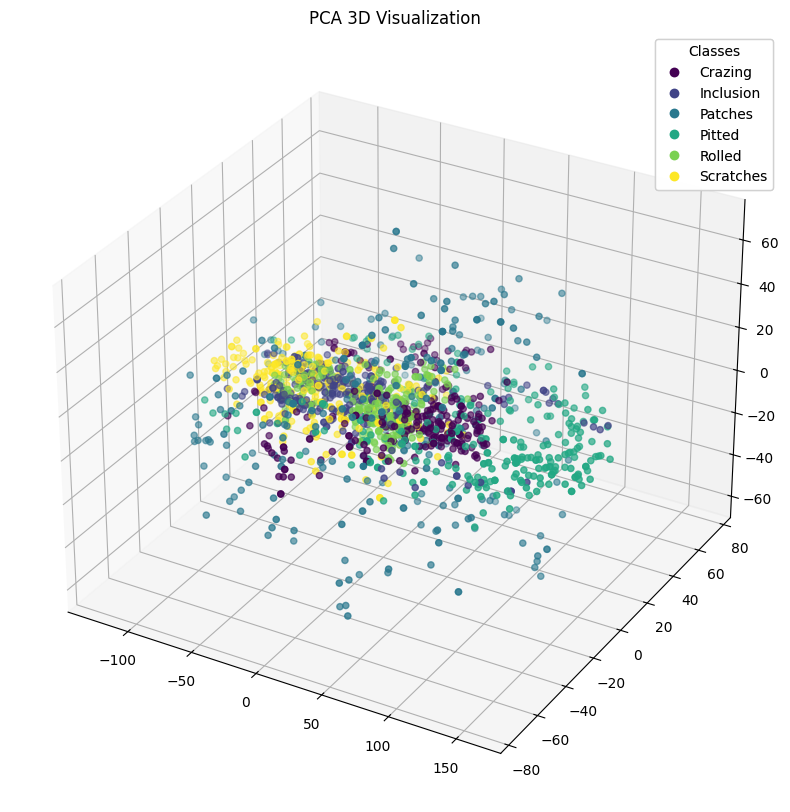

In [16]:
# PCA for 3D
class_names=list(train_generator.class_indices.keys())

pca = PCA(n_components=3)
reduced_features_3d = pca.fit_transform(flattened_features)

fig = plt.figure(figsize= (10,10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(reduced_features_3d[:, 0], reduced_features_3d[:, 1], reduced_features_3d[:, 2], c=np.argmax(train_labels, axis=1), cmap='viridis')
handles, _ = scatter.legend_elements()
legend = ax.legend(handles, class_names, title="Classes")
ax.add_artist(legend)
plt.title('PCA 3D Visualization')
plt.show()

Visualizing data in 3D using t-SNE, a nonlinear dimensionality reduction technique.

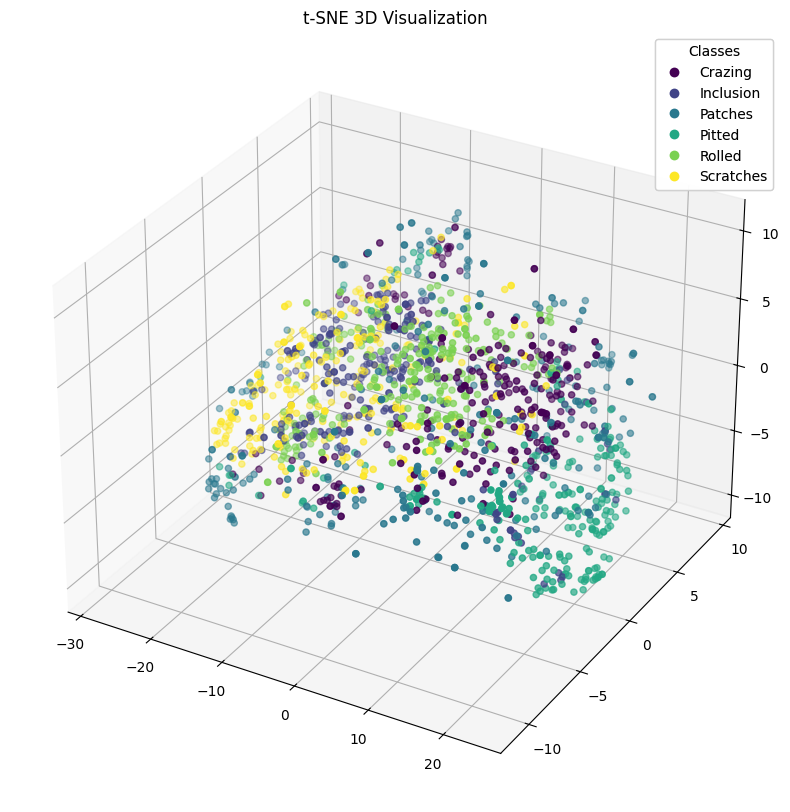

In [17]:
# t-SNE for 3D
tsne = TSNE(n_components=3, random_state=42)
tsne_features_3d = tsne.fit_transform(flattened_features)

fig = plt.figure(figsize= (10,10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(tsne_features_3d[:, 0], tsne_features_3d[:, 1], tsne_features_3d[:, 2], c=np.argmax(train_labels, axis=1), cmap='viridis')
handles, _ = scatter.legend_elements()
legend = ax.legend(handles, class_names, title="Classes")
ax.add_artist(legend)
plt.title('t-SNE 3D Visualization')
plt.show()

# 3. CNN Implementation

In [18]:
# Model layers
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
#     BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
#     Dense(64, activation='relu'),
#     Dropout(0.3),
    Dense(6 ,activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    17,334,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,429,318 (66.49 MB)

 Trainable params: 17,429,318 (66.49 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
checkpoint_cb = ModelCheckpoint(
    filepath='second/model_checkpoint_final5.keras',
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

# Early stopping callback to stop training when validation loss stops improving
early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when a metric has stopped improving
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.0001,
    verbose=1
)

# List of callbacks
callbacks = [checkpoint_cb, early_stopping_cb, reduce_lr_cb]

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model with callbacks
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=valid_generator,
    callbacks=callbacks
)

Epoch 1/25
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.2513 - loss: 1.9325
Epoch 1: val_loss improved from None to 0.79437, saving model to second/model_checkpoint_final5.keras

Epoch 1: finished saving model to second/model_checkpoint_final5.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 701ms/step - accuracy: 0.3482 - loss: 1.5483 - val_accuracy: 0.8056 - val_loss: 0.7944 - learning_rate: 0.0010
Epoch 2/25
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.6443 - loss: 0.8907
Epoch 2: val_loss improved from 0.79437 to 0.79348, saving model to second/model_checkpoint_final5.keras

Epoch 2: finished saving model to second/model_checkpoint_final5.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 23s 485ms/step - accuracy: 0.6747 - loss: 0.8440 - val_accuracy: 0.6528 - val_loss: 0.7935 - learning_rate: 0.0010
Epoch 3/25
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.7705 - loss: 0.6511
Epoch 3: val_loss improved from 0.79348 to 0.29433, saving model to second/model_checkpoint_final5.keras

E

Saving the model

In [21]:
best_model5 = load_model('second/model_checkpoint_final5.keras')

In [22]:
def plot_history(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history['val_'+metric], '')
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend([metric, 'val_'+metric])
    plt.show()

Plotting accuracy and loss for CNN Model

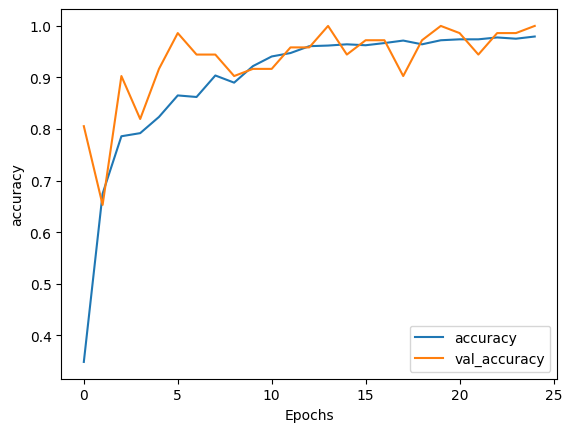

In [23]:
plot_history(history, 'accuracy')

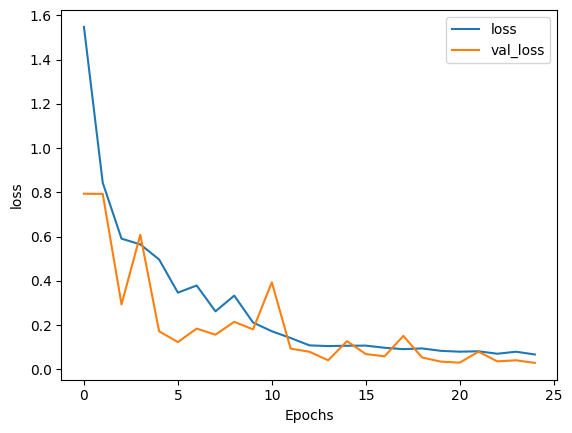

In [24]:
plot_history(history, 'loss')

Performance of CNN Model on Test Dataset

In [25]:
result = best_model5.evaluate(test_generator)
print("Test loss, Test accuracy : ", result)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9583 - loss: 0.1136 
Test loss, Test accuracy :  [0.11355376243591309, 0.9583333134651184]


Visualizing the actual and predicted labels of a few test images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


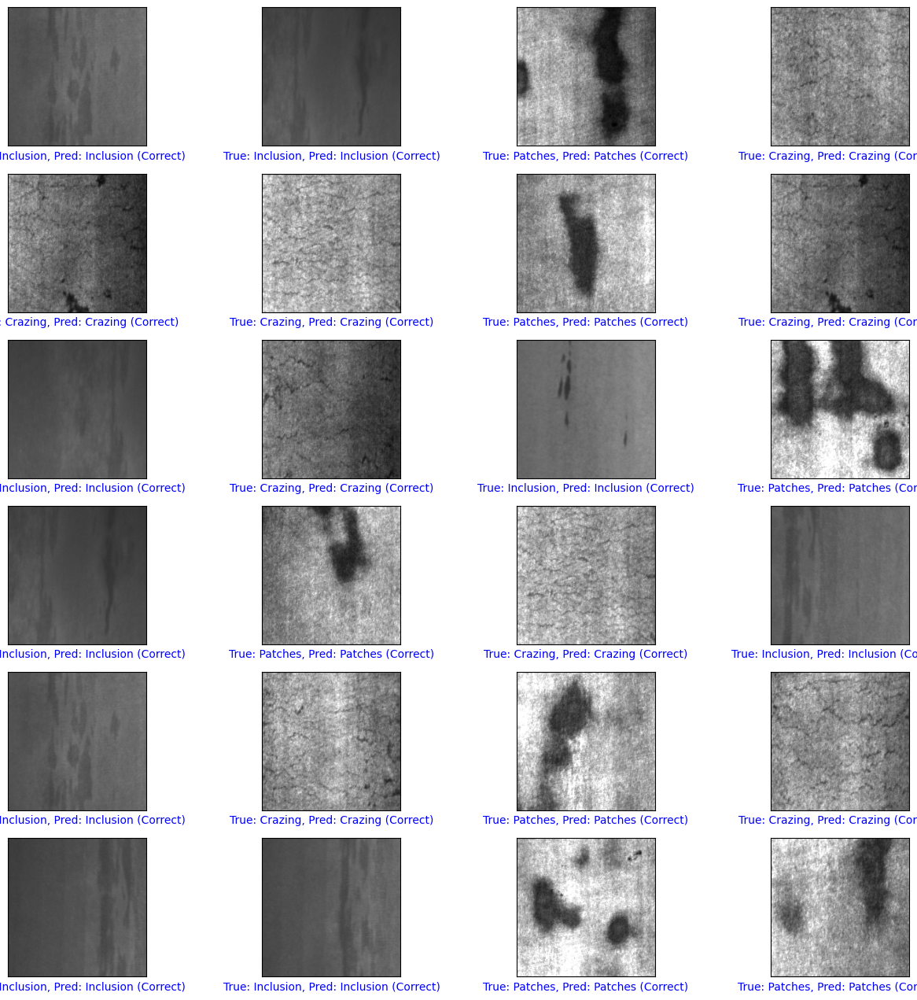

In [26]:
images, labels = next(test_generator)

indices = np.random.choice(range(len(images)), size=24)
images = images[indices]
labels = labels[indices]

predictions = best_model5.predict(images)


class_names=list(test_generator.class_indices.keys())


plt.figure(figsize=(16,16))

for i in range(24):
    plt.subplot(6,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    image = images[i]

    if image.shape[-1] == 1:
        image = np.squeeze(image)

    plt.imshow(image)

    predicted_label = np.argmax(predictions[i])

    if predicted_label == np.argmax(labels[i]):
        color='blue'
        result_text="Correct"

    else:
        color='red'
        result_text="Incorrect"

    label_text="True: "+ class_names[np.argmax(labels[i])] + ", Pred: " + class_names[predicted_label] + f" ({result_text})"

    plt.xlabel(label_text,color=color)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step 


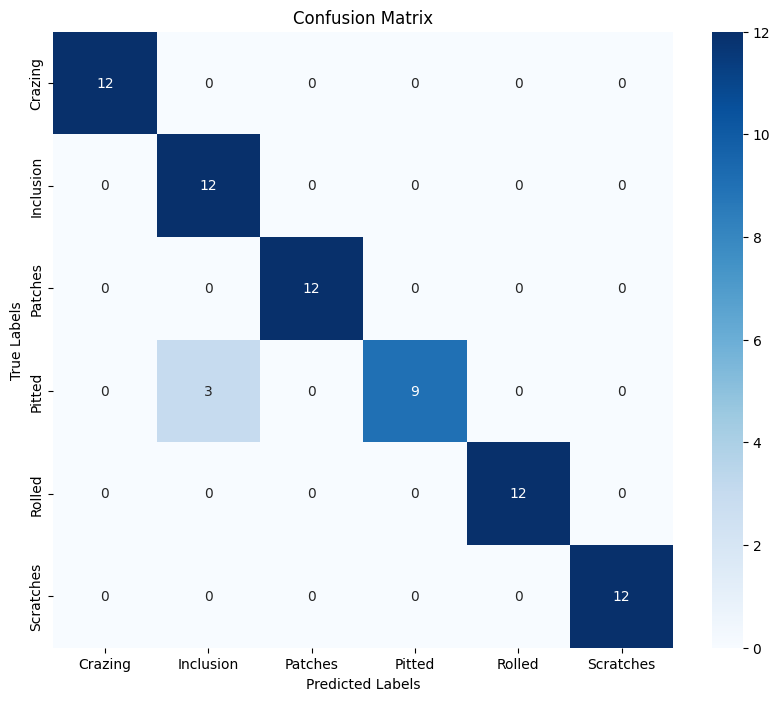

In [27]:
predictions = best_model5.predict(test_generator, verbose=1)

predicted_classes = np.argmax(predictions, axis=1)  # Get class with the highest probability
true_classes = test_generator.classes  # True labels from the generator
class_labels = list(test_generator.class_indices.keys())  # Class names

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


# 4. SVM Implementation

In [28]:
def produce_image_labels(dir):
    # Loop through each subdirectory in the root directory
    # Lists to store the features and labels
    images = []
    labels = []
    list_dir = os.listdir(dir)
    for subdirectory in list_dir:
        # Check if it is a subdirectory
        if os.path.isdir(os.path.join(dir, subdirectory)):
            # Get the full path to the subdirectory
            subdirectory_path = os.path.join(dir, subdirectory)

            # Loop through each image in the subdirectory
            for image_name in os.listdir(subdirectory_path):
            # Get the full path to the image
                image_path = os.path.join(subdirectory_path, image_name)

                # Load the image
                image = io.imread(image_path)

                # Apply HOG (Histogram of Oriented Gradients) to extract features
                features_hog, _ = feature.hog(image, visualize=True)

                # Add the features and label to the lists
                images.append(features_hog)
                labels.append(subdirectory)

    # Convert the lists to NumPy arrays
    images = np.array(images)
    labels = np.array(labels)
    return images,labels

train_images, train_labels_str = produce_image_labels(train_dir)
print("Done")
val_images, val_labels_str = produce_image_labels(valid_dir)
print("Done")
test_images, test_labels_str = produce_image_labels(test_dir)


Done
Done


HOG features are classified with an RBF-kernel SVM and a Random Forest. Both models use the same data: training and validation sets are concatenated, and hyperparameters are tuned with 3-fold cross-validation (GridSearchCV) on that combined set. The test set is used only once per model, at the end.

In [29]:
combined_images = np.concatenate([train_images, val_images])
combined_labels = np.concatenate([train_labels_str, val_labels_str])


In [31]:
svm_grid = GridSearchCV(
    SVC(kernel='rbf'),
    {'C': [10, 100], 'gamma': ['scale']},
    cv=3, n_jobs=1, verbose=3)
svm_grid.fit(combined_images, combined_labels)
print("Best SVM params:", svm_grid.best_params_)
print("Best SVM CV score:", svm_grid.best_score_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV 1/3] END .................C=10, gamma=scale;, score=0.863 total time= 2.2min
[CV 2/3] END .................C=10, gamma=scale;, score=0.814 total time= 1.8min
[CV 3/3] END .................C=10, gamma=scale;, score=0.797 total time= 1.8min
[CV 1/3] END ................C=100, gamma=scale;, score=0.863 total time= 1.9min
[CV 2/3] END ................C=100, gamma=scale;, score=0.814 total time= 1.8min
[CV 3/3] END ................C=100, gamma=scale;, score=0.797 total time= 1.8min
Best SVM params: {'C': 10, 'gamma': 'scale'}
Best SVM CV score: 0.8244273349436394


In [32]:
# GridSearchCV refits the best model on all combined data by default
test_predictions = svm_grid.predict(test_images)
test_accuracy = accuracy_score(test_labels_str, test_predictions)
print(f'SVM Test Accuracy: {test_accuracy}')


SVM Test Accuracy: 0.8611111111111112


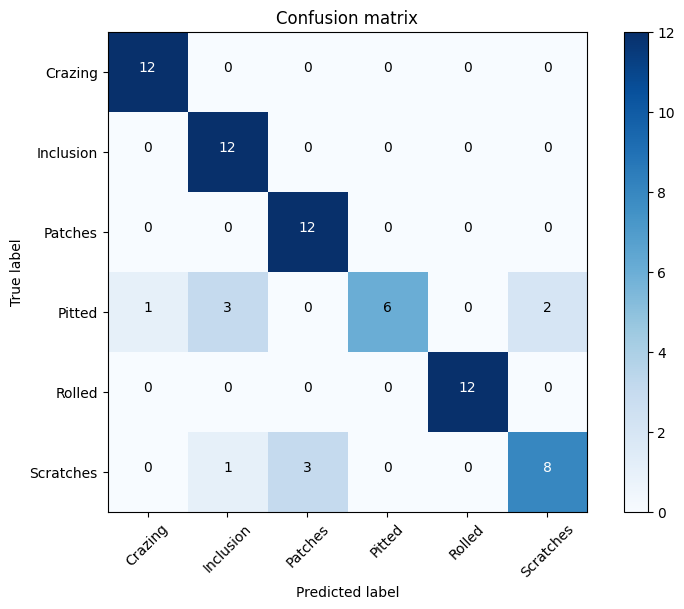

In [33]:
class_names=list(test_generator.class_indices.keys())
# Calculate the confusion matrix
svm_confusion_matrix = confusion_matrix(test_labels_str, test_predictions)

# Function to plot the confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
plot_confusion_matrix(svm_confusion_matrix, class_names)
plt.show()

# 5. Random Forest

In [36]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [200], 'max_depth': [20, None],
     'min_samples_leaf': [2], 'max_features': ['sqrt']},
    cv=3, n_jobs=2, verbose=3)
rf_grid.fit(combined_images, combined_labels)
print("Best RF params:", rf_grid.best_params_)
print("Best RF CV score:", rf_grid.best_score_)


Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best RF params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
Best RF CV score: 0.6807497987117553


In [37]:
test_predictions_rf = rf_grid.predict(test_images)
rf_test_accuracy = accuracy_score(test_labels_str, test_predictions_rf)
print(f"RF Test Accuracy: {rf_test_accuracy}")


RF Test Accuracy: 0.625


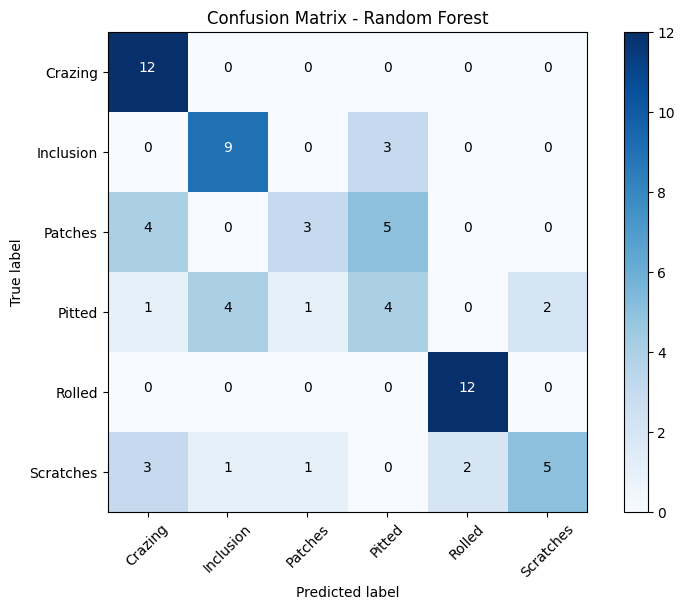

In [38]:
# Plot the Random Forest confusion matrix
confusion_matrix_rf = confusion_matrix(test_labels_str, test_predictions_rf)

plt.figure(figsize=(8, 6))
plot_confusion_matrix(confusion_matrix_rf, class_names)
plt.title('Confusion Matrix - Random Forest')
plt.show()

# 6. Model Comparison

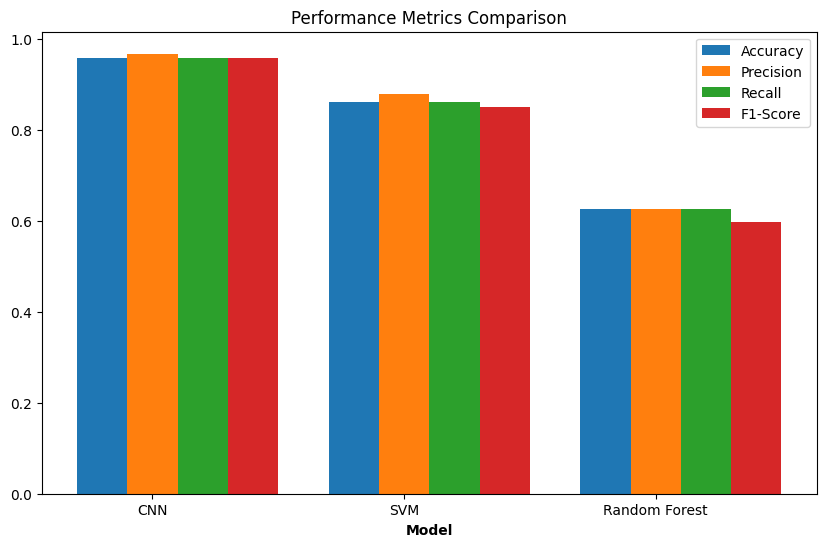

CNN: acc=0.9583 precision=0.9667 recall=0.9583 f1=0.9577
SVM: acc=0.8611 precision=0.8788 recall=0.8611 f1=0.8500
Random Forest: acc=0.6250 precision=0.6246 recall=0.6250 f1=0.5963


In [39]:
accuracy_cnn = accuracy_score(true_classes, predicted_classes)
precision_cnn = precision_score(true_classes, predicted_classes, average='weighted')
recall_cnn = recall_score(true_classes, predicted_classes, average='weighted')
f1_cnn = f1_score(true_classes, predicted_classes, average='weighted')

# print(f'CNN Accuracy: {accuracy_cnn:.2f}')
# print(f'CNN Precision: {precision_cnn:.2f}')
# print(f'CNN Recall: {recall_cnn:.2f}')
# print(f'CNN F1-Score: {f1_cnn:.2f}')

accuracy_svm = accuracy_score(test_labels_str, test_predictions)
precision_svm = precision_score(test_labels_str, test_predictions, average='weighted')
recall_svm = recall_score(test_labels_str, test_predictions, average='weighted')
f1_svm = f1_score(test_labels_str, test_predictions, average='weighted')

# print(f'SVM Accuracy: {accuracy_svm:.2f}')
# print(f'SVM Precision: {precision_svm:.2f}')
# print(f'SVM Recall: {recall_svm:.2f}')
# print(f'SVM F1-Score: {f1_svm:.2f}')

accuracy_rf = accuracy_score(test_labels_str, test_predictions_rf)
precision_rf = precision_score(test_labels_str, test_predictions_rf, average='weighted')
recall_rf = recall_score(test_labels_str, test_predictions_rf, average='weighted')
f1_rf = f1_score(test_labels_str, test_predictions_rf, average='weighted')

# print(f'Random Forest Accuracy: {accuracy_rf:.2f}')
# print(f'Random Forest Precision: {precision_rf:.2f}')
# print(f'Random Forest Recall: {recall_rf:.2f}')
# print(f'Random Forest F1-Score: {f1_rf:.2f}')

models = ['CNN', 'SVM', 'Random Forest']
accuracies = [accuracy_cnn, accuracy_svm, accuracy_rf]
precisions = [precision_cnn, precision_svm, precision_rf]
recalls = [recall_cnn, recall_svm, recall_rf]
f1_scores = [f1_cnn, f1_svm, f1_rf]

barWidth = 0.2
r1 = np.arange(len(accuracies))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]

plt.figure(figsize=(10, 6))

plt.bar(r1, accuracies, width=barWidth, label='Accuracy')
plt.bar(r2, precisions, width=barWidth, label='Precision')
plt.bar(r3, recalls, width=barWidth, label='Recall')
plt.bar(r4, f1_scores, width=barWidth, label='F1-Score')

plt.xlabel('Model', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(accuracies))], models)
plt.title('Performance Metrics Comparison')
plt.legend()

plt.show()
for name, a, p, r, f in zip(models, accuracies, precisions, recalls, f1_scores):
    print(f'{name}: acc={a:.4f} precision={p:.4f} recall={r:.4f} f1={f:.4f}')


Visualizing Pitted vs Inclusion...


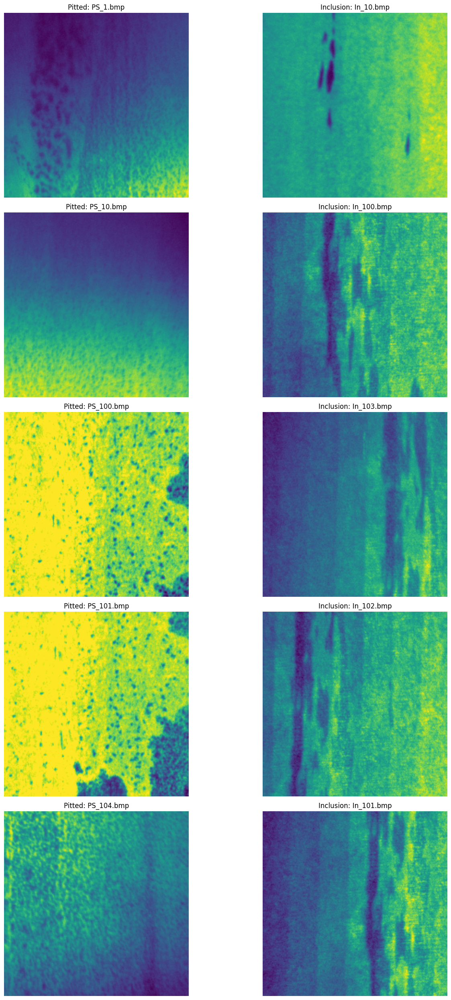

Visualizing Scratches vs Patches...


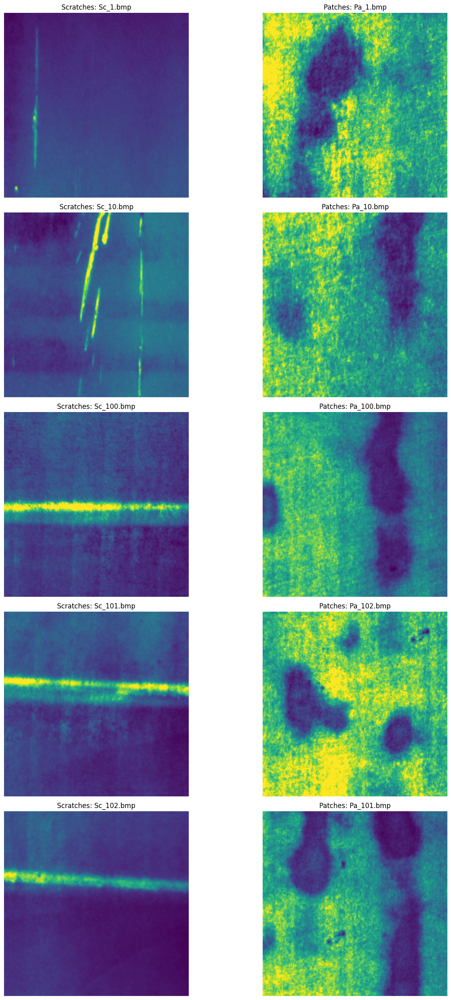

In [40]:
# Confused classes
confused_classes = [
    ("Pitted", "Inclusion"),
    ("Scratches", "Patches")
]

# Function to load a few images from each class
def load_images_for_visualization(directory, class1, class2, num_images=5):
    class1_dir = os.path.join(directory, class1)
    class2_dir = os.path.join(directory, class2)

    class1_images = [os.path.join(class1_dir, img) for img in os.listdir(class1_dir)[:num_images]]
    class2_images = [os.path.join(class2_dir, img) for img in os.listdir(class2_dir)[:num_images]]

    return class1_images, class2_images

# Visualize images side-by-side
def visualize_images(images1, images2, label1, label2):
    num_images = min(len(images1), len(images2))
    plt.figure(figsize=(15, num_images * 5))

    for i in range(num_images):
        # Load images
        img1 = Image.open(images1[i])
        img2 = Image.open(images2[i])

        # Plot side by side
        plt.subplot(num_images, 2, i * 2 + 1)
        plt.imshow(img1)
        plt.axis('off')
        plt.title(f"{label1}: {os.path.basename(images1[i])}")

        plt.subplot(num_images, 2, i * 2 + 2)
        plt.imshow(img2)
        plt.axis('off')
        plt.title(f"{label2}: {os.path.basename(images2[i])}")

    plt.tight_layout()
    plt.show()

# Visualize confused classes
for class1, class2 in confused_classes:
    print(f"Visualizing {class1} vs {class2}...")
    images1, images2 = load_images_for_visualization(test_dir, class1, class2, num_images=5)
    visualize_images(images1, images2, class1, class2)


# 7. How reliable are these numbers?
The test set has only 72 images, so one image is about 1.4 percentage points. The 95% Wilson confidence intervals below show how much the accuracies could move on a different test sample.

In [41]:
import math

def wilson_interval(correct, n, z=1.96):
    p = correct / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centre - half, centre + half

n_test = len(test_labels_str)
for name, acc in zip(models, accuracies):
    correct = round(acc * n_test)
    lo, hi = wilson_interval(correct, n_test)
    print(f"{name}: {correct}/{n_test} correct, accuracy {acc:.4f}, 95% CI ({lo:.3f}, {hi:.3f})")


CNN: 69/72 correct, accuracy 0.9583, 95% CI (0.885, 0.986)
SVM: 62/72 correct, accuracy 0.8611, 95% CI (0.763, 0.923)
Random Forest: 45/72 correct, accuracy 0.6250, 95% CI (0.510, 0.728)
